# Notebook for Data Analysis

In [12]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Load Human fMRI data

Due to privacy human data is not shared in this repository.

In [2]:
anatomical_paths = [
    'Human\\aseg1.nii.gz',
    'Human\\aseg2.nii.gz',
    'Human\\aseg3.nii.gz',
    'Human\\aseg4.nii.gz',
    'Human\\aseg5.nii.gz',
    'Human\\aseg6.nii.gz',
    'Human\\aseg7.nii.gz',
    'Human\\aseg8.nii.gz',
    'Human\\aseg9.nii.gz',
    'Human\\aseg10.nii.gz',
    'Human\\aseg11.nii.gz',
    'Human\\aseg12.nii.gz',
    'Human\\aseg13.nii.gz',
    'Human\\aseg14.nii.gz',
    'Human\\aseg15.nii.gz',
    'Human\\aseg16.nii.gz',
    'Human\\aseg17.nii.gz'
]

fmri_paths = [
    'Human\cASL1.nii.gz',
    'Human\cASL2.nii.gz',
    'Human\cASL3.nii.gz',
    'Human\cASL4.nii.gz',
    'Human\cASL5.nii.gz',
    'Human\cASL6.nii.gz',
    'Human\cASL7.nii.gz',
    'Human\cASL8.nii.gz',
    'Human\cASL9.nii.gz',
    'Human\cASL10.nii.gz',
    'Human\cASL11.nii.gz',
    'Human\cASL12.nii.gz',
    'Human\cASL13.nii.gz',
    'Human\cASL14.nii.gz',
    'Human\cASL15.nii.gz',
    'Human\cASL16.nii.gz',
    'Human\cASL17.nii.gz'
]


In [ ]:
def load_and_extract(file_paths):
    """
    Loads images from a list of file paths and extracts the NumPy array.

    Args:
        file_paths (list): A list of strings, where each string is a path to a NIfTI file.
        data_list (list): The list to which the extracted NumPy arrays will be appended.
    """
    data_list = []
    for file_path in file_paths:
        try:
            # Load the NIfTI image using nibabel
            img = nib.load(file_path)
            # Extract the data as a NumPy array
            data_array = img.get_fdata()
            data_list.append(data_array)
            print(f"Successfully loaded and extracted data from: {file_path}")
        except FileNotFoundError:
            print(f"Error: The file was not found at {file_path}")
        except Exception as e:
            print(f"An error occurred while processing {file_path}: {e}")
    return data_list
print("--- Loading Anatomical Images ---")
anatomical_data = load_and_extract(anatomical_paths)
print("--- Loading fMRI Images ---")
fmri_data       = load_and_extract(fmri_paths)

In [5]:
def extract_fmri_data(antomical,fmri):
    """
    Parameters
    ----------
    antomical : TYPE list
        DESCRIPTION: the file path of the anatomical MRI (labels)
    fmri : TYPE
        DESCRIPTION. the file path of the cASL MRI (fmri data) 
    Returns
    -------
    TYPE list
        DESCRIPTION. retruns the ASL values of the WM of the brain
    """
    if len(antomical) != len(fmri):
        print('error, lenght of list should be the same')
        return 0
    else:
        data_list = []
        for index in range(len(fmri)):
            image                                                    = fmri[index] # new
            image[image<0]                                           = 0           # new
            x,y,z                                                    = fmri[index].shape
            mask                                                     = np.zeros([x,y,z])
            mask[(antomical[index] == 41) | (antomical[index] == 2)] = 1
            # mask[(antomical[index] == 5)] = 1
            # Extract                                                  = mask*fmri[index]
            Extract                                                  = mask*image # new
            data_list.append(Extract[np.nonzero(Extract)]/10)
        return data_list
def extract_fmri_data_gm(antomical,fmri):
    """
    Parameters
    ----------
    antomical : TYPE list
        DESCRIPTION: the file path of the anatomical MRI (labels)
    fmri : TYPE
        DESCRIPTION. the file path of the cASL MRI (fmri data) 
    Returns
    -------
    TYPE list
        DESCRIPTION. retruns the ASL values of the WM of the brain
    """
    if len(antomical) != len(fmri):
        print('error, lenght of list should be the same')
        return 0
    else:
        data_list = []
        for index in range(len(fmri)):
            image                                                    = fmri[index] # new
            image[image<0]                                           = 0           # new
            x,y,z                                                    = fmri[index].shape
            mask                                                     = np.zeros([x,y,z])
            mask[(antomical[index] == 42) | (antomical[index] == 3)] = 1
            # mask[(antomical[index] == 5)] = 1
            # Extract                                                  = mask*fmri[index]
            Extract                                                  = mask*image # new
            data_list.append(Extract[np.nonzero(Extract)]/10)
        return data_list
print("--- Extracting fMRI Data ---")
wm_asl_list     = extract_fmri_data(anatomical_data,fmri_data)
gm_asl_list     = extract_fmri_data_gm(anatomical_data,fmri_data)    

--- Extracting fMRI Data ---


## Load Phantom fMRI data

In [ ]:
phantom_asl = [
    'QASPER\\ASL1.nii',
    'QASPER\\cASL2.nii.gz',
    'QASPER\\cASL3.nii.gz',
    'QASPER\\cASL4.nii.gz',
    'QASPER\\cASL5.nii.gz',
    'QASPER\\cASL6.nii.gz',
    'QASPER\\cASL7.nii.gz',
    'QASPER\\cASL8.nii.gz',
    'QASPER\\cASL9.nii.gz',
    'QASPER\\cASL10.nii.gz',
    'QASPER\\cASL11.nii.gz',
    'QASPER\\cASL12.nii.gz',
    'QASPER\\cASL13.nii.gz',
    'QASPER\\cASL14.nii.gz',
    'QASPER\\cASL15.nii.gz',
    'QASPER\\cASL16.nii.gz',
    'QASPER\\cASL17.nii.gz'
]
print("--- Loading Phantom Images ---")
phantom_data    = load_and_extract(phantom_asl)

In [ ]:
def phantom_extract_data(phantom_list,flag_circle):
    x,y,z = phantom_list[0].shape
    if flag_circle:
        center           = ((x // 2)+1, (y // 2)-2)
        inner_radius0 = 40
        Y, X             = np.ogrid[:x, :y]
        dist_from_center = np.sqrt((X - center[0])**2 + (Y - center[1])**2)
        mask             = dist_from_center <= inner_radius0
    else:
        center           = ((x // 2)+1, (y // 2)-2)
        inner_radius0 = 22; outer_radius0 = 30
        Y, X             = np.ogrid[:x, :y]
        dist_from_center = np.sqrt((X - center[0])**2 + (Y - center[1])**2)
        mask             = (dist_from_center >= inner_radius0) & (dist_from_center <= outer_radius0) 
    output_data= []
    for i in range(len(phantom_list)):
        S2          = phantom_list[i][:,:,10]*mask
        S3          = phantom_list[i][:,:,11]*mask
        S4          = phantom_list[i][:,:,12]*mask
        data        = np.concatenate([S2,S3,S4])
        data = data * 0.32/0.9
        data[(data < 0.18) & (data > 0.17)] = 0
        output_data.append(data[np.nonzero(data)]/10)
    return output_data
print("--- Extracting Phantom data ---")
asl_data_pantom = phantom_extract_data(phantom_data,True)

--- Extracting Phantom data ---


## Create Dataframe with the input MRI data

In [10]:
def prepare_dataframe(human_dataWM, human_dataGM, phantom_data):
    """
    Converts the raw data lists into a long-form pandas DataFrame.
    This format is ideal for analysis and plotting.
    
    Args:
        human_data (list): List of 17 numpy arrays for human measurements.
        phantom_data (list): List of 17 numpy arrays for phantom measurements.
        
    Returns:
        pd.DataFrame: A long-form DataFrame with columns ['day', 'source', 'value'].
    """
    data = []
    for i, day_data in enumerate(human_dataWM):
        for value in day_data:
            data.append({'day': i + 1, 'source': 'HumanWM', 'value': value})
            
    for i, day_data in enumerate(human_dataGM):
        for value in day_data:
            data.append({'day': i + 1, 'source': 'HumanGM', 'value': value})
            
    for i, day_data in enumerate(phantom_data):
        for value in day_data:
            data.append({'day': i + 1, 'source': 'Phantom', 'value': value})
            
    return pd.DataFrame(data)
print("--- Converting data to dataframe ---")
df              = prepare_dataframe(wm_asl_list,gm_asl_list,asl_data_pantom)

--- Converting data to dataframe ---


In [ ]:
def step_1_exploration(df):
    """
    Performs initial data exploration: calculates descriptive statistics and
    saves the df in a spreadsheet.
    
    Args:
        df (pd.DataFrame): The long-form data.
    """
    print("\n--- Step 1: Descriptive Statistics ---")
        # Calculate and print descriptive statistics for each group and day
    desc_stats = df.groupby(['source', 'day'])['value'].describe()
    print("Descriptive Statistics:")
    print(desc_stats.to_string())
    print("\n--- Step 2: Save spreadsheet file ---")
    desc_stats.to_excel("Descriptive_full.xlsx", index=False)
step_1_exploration(df)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


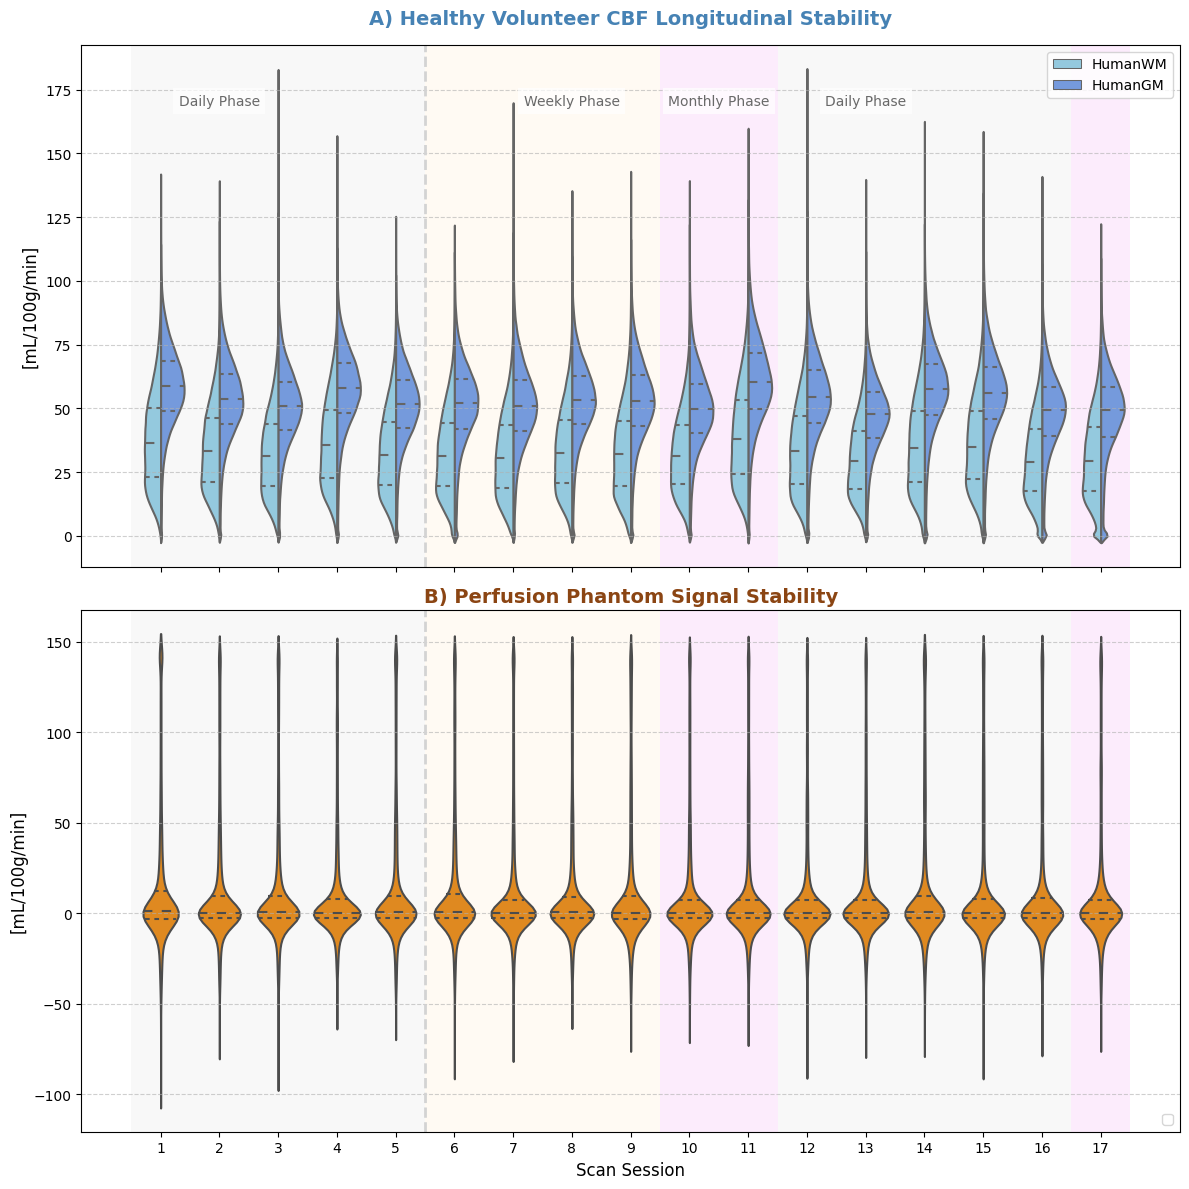

In [ ]:
def step2_figure(df):
    sessions = np.arange(1, 16)
    median_df = df.groupby(['source', 'day'])['value'].median().reset_index()
    mean_df = df.groupby(['source', 'day'])['value'].mean().reset_index()
    # --- 2. Create Two-Panel Figure ---
    fig, axes = plt.subplots(2, 1, figsize=(12, 12), sharex=True)
    plt.subplots_adjust(hspace=0.05) # Reduce space between subplots
    # Define colors
    human_color = 'skyblue'
    phantom_color = 'darkorange'
    # --- PANEL A: Healthy Volunteer (Blue) ---
    ax_human = axes[0]
    human_df = df[df['source'].isin(['HumanWM', 'HumanGM'])]
    human_meanWM = mean_df[mean_df['source'] == 'HumanWM']
    # A.1. Violin Plot for Distribution
    sns.violinplot(
        x='day', y='value', data=human_df, hue='source', ax=ax_human,
        palette={'HumanWM':'skyblue', 'HumanGM':'cornflowerblue'},
        inner='quartile', linewidth=1.5, split=True)
    

    ax_human.set_title('A) Healthy Volunteer CBF Longitudinal Stability', color='steelblue', fontsize=14, fontweight='bold',pad=15)
    ax_human.set_ylabel('[mL/100g/min]', fontsize=12)
    ax_human.set_xlabel('') # Shared X-axis
    ax_human.grid(axis='y', linestyle='--', alpha=0.6)
    ax_human.legend(loc='upper right')
    
    # --- PANEL B: Perfusion Phantom (Orange) ---
    ax_phantom = axes[1]
    phantom_df = df[df['source'] == 'Phantom']
    phantom_mean = mean_df[mean_df['source'] == 'Phantom']
    phantom_median = median_df[median_df['source'] == 'Phantom']
    
    # B.1. Violin Plot for Distribution
    sns.violinplot(
        x='day', y='value', data=phantom_df, ax=ax_phantom,
        color=phantom_color, inner='quartile', linewidth=1.5
    )
        
    ax_phantom.set_title('B) Perfusion Phantom Signal Stability', color='saddlebrown', fontsize=14, fontweight='bold')
    ax_phantom.set_ylabel('[mL/100g/min]', fontsize=12)
    ax_phantom.set_xlabel('Scan Session', fontsize=12)
    ax_phantom.grid(axis='y', linestyle='--', alpha=0.6)
    ax_phantom.legend(loc='lower right')
    
    # --- 3. Add Visual Annotation for Sampling Phases (Applied to both) ---
    # Phase change occurs after Session 5 (between index 4 and 5)
    phase_change_x = 4.5
    phase_color = 'lightgray'
    phase_alpha = 0.15
    
    # Add vertical line separating phases
    axes[0].axvline(x=phase_change_x, color=phase_color, linestyle='--', linewidth=2)
    axes[1].axvline(x=phase_change_x, color=phase_color, linestyle='--', linewidth=2)
    
    # Shade and label the 'Daily' phase (Sessions 1-5)
    axes[0].axvspan(-0.5, phase_change_x, facecolor=phase_color, alpha=phase_alpha, zorder=0)
    axes[1].axvspan(-0.5, phase_change_x, facecolor=phase_color, alpha=phase_alpha, zorder=0)
    axes[0].text(1.0, ax_human.get_ylim()[1]*0.90, 'Daily Phase', ha='center', va='top', fontsize=10, color='dimgray', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    
    # Shade and label the 'Weekly' phase (Sessions 6-9)
    axes[0].axvspan(phase_change_x, 8.5, facecolor='Moccasin', alpha=phase_alpha, zorder=0)
    axes[1].axvspan(phase_change_x, 8.5, facecolor='Moccasin', alpha=phase_alpha, zorder=0)
    axes[0].text(7.0, ax_human.get_ylim()[1]*0.90, 'Weekly Phase', ha='center', va='top', fontsize=10, color='dimgray', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    
    axes[0].axvspan(8.5, 10.5, facecolor='violet', alpha=phase_alpha, zorder=0)
    axes[1].axvspan(8.5, 10.5, facecolor='violet', alpha=phase_alpha, zorder=0)
    axes[0].text(9.5, ax_human.get_ylim()[1]*0.90, 'Monthly Phase', ha='center', va='top', fontsize=10, color='dimgray', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    axes[0].axvspan(10.5, 15.5, facecolor=phase_color, alpha=phase_alpha, zorder=0)
    axes[1].axvspan(10.5, 15.5, facecolor=phase_color, alpha=phase_alpha, zorder=0)
    axes[0].text(12.0, ax_human.get_ylim()[1]*0.90, 'Daily Phase', ha='center', va='top', fontsize=10, color='dimgray', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    
    axes[0].axvspan(15.5, 16.5, facecolor='violet', alpha=phase_alpha, zorder=0)
    axes[1].axvspan(15.5, 16.5, facecolor='violet', alpha=phase_alpha, zorder=0)
    
    # Correct X-axis labels to show 'Session 1' to 'Session 9'
    x_ticks = np.arange(17)
    x_labels = [f'S{i}' for i in sessions]
    ax_phantom.set_xticks(x_ticks)
    # ax_phantom.set_xticklabels(x_labels)
    
    # fig.suptitle(Longitudinal Distribution and Trend of ASL Metrics', fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout()
    # plt.savefig('longitudinal_stability_two_panel.png')
    plt.show()
step2_figure(df)

In [ ]:
# File path
file_path = "Descriptive_full.xlsx"

# Read the Excel file
df = pd.read_excel(file_path)

# Expected columns
expected_cols = ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']

# Check if columns match exactly
if list(df.columns) == expected_cols:
    
    total_rows = len(df)
    
    # Ensure divisible by 3
    if total_rows % 3 != 0:
        raise ValueError("Number of rows is not divisible by 3.")
    
    N = total_rows // 3

    # Create 'source' column
    source_col = (['HumanGM'] * N +
                  ['HumanWM'] * N +
                  ['Phantom'] * N)

    # Create 'day' column
    day_col = list(range(1, N + 1)) * 3

    # Insert columns at the beginning
    df.insert(0, 'source', source_col)
    df.insert(1, 'day', day_col)

    # Save back to Excel (overwrite)
    df.to_excel(file_path, index=False)

    print("File updated successfully.")

else:
    print("Columns do not match expected format. No changes made.")

File updated successfully.


[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]
33.964177369454234 2.624138360531502 7.726194372343395
52.62559774987639 3.8969045548727546 7.404960174313474


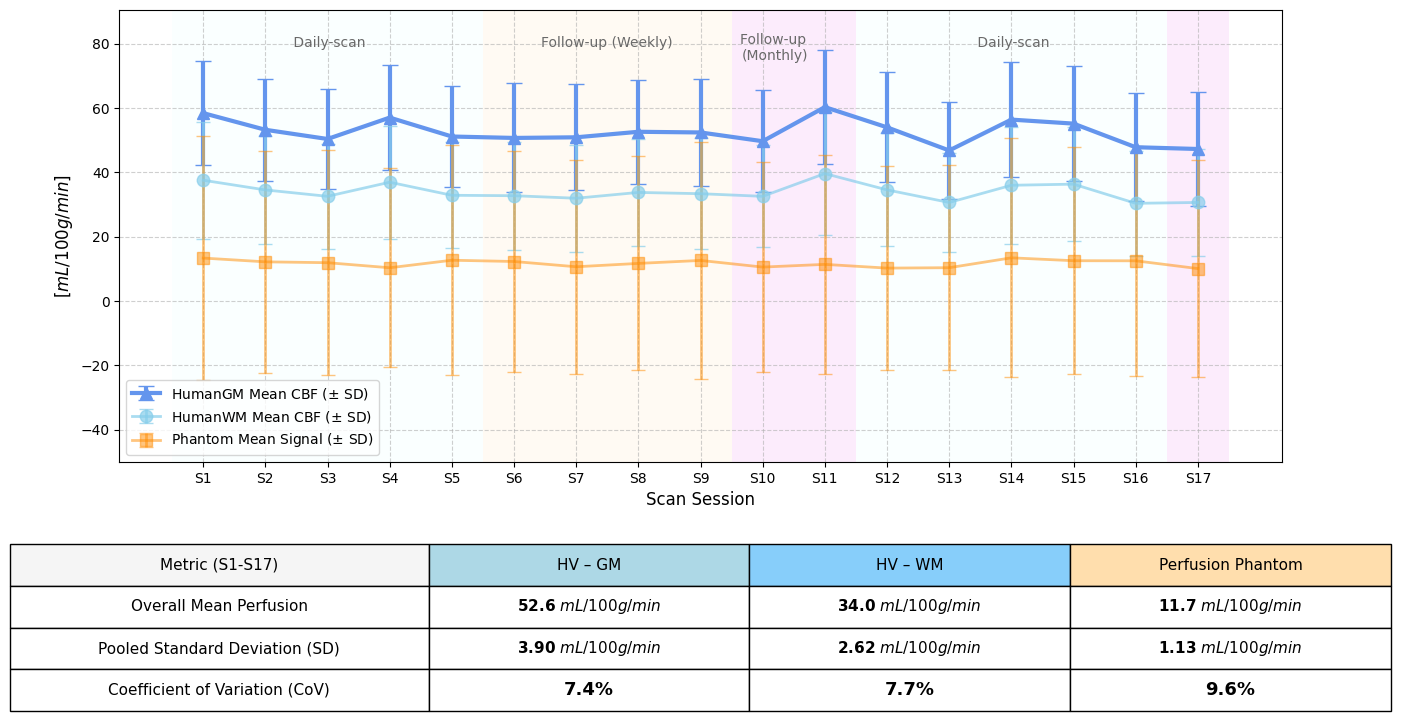

In [23]:
def step4_mean_variability_figure(file_path):
    """
    Generates the Longitudinal Mean and Variability Comparison figure (Figure 3) 
    from a summary Excel file containing session mean, std, and count.
    """
    try:
        df = pd.read_excel(file_path)
    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
        return

    # --- Data Filtering and Setup ---
    sessions = df['day'].unique()
    print(sessions )
    
    # Calculate Overall Statistics (Weighted Pooled SD and CoV)
    def calculate_overall_stats_from_summary(df_source):
        k            = len(df_source)
        overall_mean = df_source['mean'].sum() / k
        pooled_std   = df_source['mean'].std()
        # CoV
        cov = (pooled_std / overall_mean) * 100
        return overall_mean, pooled_std, cov

    # human_df = df[df['source'] == 'Human'].copy()
    humanWM_df = df[df['source'] == 'HumanWM'].copy()
    humanGM_df = df[df['source'] == 'HumanGM'].copy()
    phantom_df = df[df['source'] == 'Phantom'].copy()
    # print(human_df)
    # print(phantom_df)
    human_meanWM, human_stdWM, human_covWM = calculate_overall_stats_from_summary(humanWM_df)
    human_meanGM, human_stdGM, human_covGM = calculate_overall_stats_from_summary(humanGM_df)
    phantom_mean, phantom_std, phantom_cov = calculate_overall_stats_from_summary(phantom_df)
    print(human_meanWM,human_stdWM,human_covWM)
    print(human_meanGM,human_stdGM,human_covGM)
    # Define colors
    human_colorWM = 'skyblue'
    human_colorGM = 'cornflowerblue'
    phantom_color = 'darkorange'
    phase_color_daily = 'lightcyan'
    phase_color_weekly = 'Moccasin'
    phase_color_monthly = 'violet'
    phase_alpha = 0.15

    # --- 3. Create Figure Layout (Panel A: Plot, Panel B: Table) ---
    fig = plt.figure(figsize=(15, 9))
    gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.3)

    # --- Panel A: Line Plot with Error Bars ---
    ax_plot = fig.add_subplot(gs[0])
    # ax_plot.set_title('A) Longitudinal Trend and Session Variability ($\pm$ SD)', fontsize=16, fontweight='bold', pad=15)
    ax_plot.set_xlabel('Scan Session', fontsize=12)

    # Plotting Human Data
    ax_plot.errorbar(
        humanGM_df['day'], humanGM_df['mean'], yerr=humanGM_df['std'], 
        fmt='-^', capsize=6, color=human_colorGM, linewidth=3, markersize=9, label='HumanGM Mean CBF ($\pm$ SD)',alpha=1
    )
    ax_plot.errorbar(
        humanWM_df['day'], humanWM_df['mean'], yerr=humanWM_df['std'], 
        fmt='-o', capsize=5, color=human_colorWM, linewidth=2, markersize=9, label='HumanWM Mean CBF ($\pm$ SD)',alpha=0.7
    )

    # Plotting Phantom Data
    ax_plot.errorbar(
        phantom_df['day'], phantom_df['mean'], yerr=phantom_df['std'], 
        fmt='-s', capsize=5, color=phantom_color, linewidth=2, markersize=9, label='Phantom Mean Signal ($\pm$ SD)', alpha = 0.5
    )

    # Add Annotation for Phases
    ax_plot.axvspan(0.5, 5.5, facecolor=phase_color_daily, alpha=phase_alpha, zorder=0)
    ax_plot.axvspan(5.5, 9.5, facecolor=phase_color_weekly, alpha=phase_alpha, zorder=0)
    ax_plot.axvspan(9.5, 11.5, facecolor=phase_color_monthly, alpha=phase_alpha, zorder=0)
    ax_plot.axvspan(11.5, 16.5, facecolor=phase_color_daily, alpha=phase_alpha, zorder=0)
    ax_plot.axvspan(16.5, 17.5, facecolor=phase_color_monthly, alpha=phase_alpha, zorder=0)

    y_max = max(ax_plot.get_ylim())
    y_pos_text = y_max * 0.99

    ax_plot.text(3, y_pos_text, ' Daily-scan', ha='center', va='top', fontsize=10, color='dimgray')
    ax_plot.text(7.5, y_pos_text, 'Follow-up (Weekly)', ha='center', va='top', fontsize=10, color='dimgray')
    ax_plot.text(10.2, y_pos_text+1, 'Follow-up \n(Monthly)', ha='center', va='top', fontsize=10, color='dimgray')
    ax_plot.text(14, y_pos_text, ' Daily-scan', ha='center', va='top', fontsize=10, color='dimgray')

    ax_plot.grid(True, linestyle='--', alpha=0.6)
    ax_plot.legend(loc='lower left', frameon=True)
    ax_plot.set_xticks(sessions)
    ax_plot.set_xticklabels([f'S{i}' for i in sessions])
    ax_plot.set_ylabel('[$mL/100g/min$]', fontsize=12) 
    ax_plot.set_ylim(-50., 90.5)
    # ax_plot.set_xlim(0.5, 9.5)


    # --- Panel B: Summary Statistics Table ---
    ax_table = fig.add_subplot(gs[1])
    ax_table.axis('off')

    # Prepare table data
    data = [
    ['Overall Mean Perfusion',
     rf"$\mathbf{{{human_meanGM:.1f}}}$ $mL/100g/min$",
     rf"$\mathbf{{{human_meanWM:.1f}}}$ $mL/100g/min$",
     rf"$\mathbf{{{phantom_mean:.1f}}}$ $mL/100g/min$"],

    ['Pooled Standard Deviation (SD)',
     rf"$\mathbf{{{human_stdGM:.2f}}}$ $mL/100g/min$",
     rf"$\mathbf{{{human_stdWM:.2f}}}$ $mL/100g/min$",
     rf"$\mathbf{{{phantom_std:.2f}}}$ $mL/100g/min$"],

    ['Coefficient of Variation (CoV)',
     f'{human_covGM:.1f}%',
     f'{human_covWM:.1f}%',
     f'{phantom_cov:.1f}%']]

    col_labels = ['Metric (S1-S17)', 'HV – GM', 'HV – WM', 'Perfusion Phantom']
    col_colors = ['#f5f5f5', 'lightblue', 'lightskyblue', 'navajowhite']

    table = ax_table.table(
        cellText=data,
        colLabels=col_labels,
        colColours=col_colors,
        loc='center',
        cellLoc='center',
        colWidths=[0.30, 0.23, 0.23, 0.23]
    )

    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 2.5)

    # Highlight CoV row (index 3)
    for i in [1, 2, 3]:
        cell = table[(3, i)]
        # cell.set_facecolor('lightcoral' if i==1 else 'lightsalmon') 
        cell.get_text().set_fontweight('bold')
        cell.get_text().set_fontsize(13)
step4_mean_variability_figure("Descriptive_full.xlsx")